<a href="https://colab.research.google.com/github/akosinyll1404/Machine-Learning-Projects/blob/main/Case_Study_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Technological Institute of the Philippines | Quezon City - Computer Engineering
--- | ---
Course Code: | CPE 312
Code Title: | Predictive Analytics using Machine Learning
1st Semester | AY 2024-2025
<hr> | <hr>
<u>**Case Study 1** | **Regression**
**Name** | Cuadra, Delos Reyes, Sumilang, Padrigano
**Section** | CPE31S3
**Date Performed**: | December 2, 2024
**Date Submitted**: | December 11, 2024
**Instructor**: | Dr. Alonica Villanueva

<hr>

# About the Dataset
This dataset comprises temperature and humidity readings collected from various locations within the Technological Institute of the Philippines, Quezon City campus over a one-week period. The data was gathered using sensors placed in open and closed spaces, including the PE Center, Building 5, the Library (Building 8), and the Study Hall.

Readings were taken and averaged every 5 minutes, providing a comprehensive view of environmental conditions across the campus. The dataset includes the following features:

* Timestamp: Date and time of the recorded data.
* Average_Temperature_(°C): Average temperature in Celsius during the 5-minute interval.
* Average_Humidity_(%): Average humidity percentage during the 5-minute interval.
* Space: Indicates whether the location is an open or closed space (Open, Close).
* Area: Specifies the specific area where the data was collected (PE Center, Building 5, Library, Study Hall).

This dataset can be used to analyze temperature and humidity patterns across different areas and space types within the campus, potentially revealing insights into energy consumption, student comfort, and environmental factors that influence these conditions.

# Data Preprocessing

## Dataset for PE Center

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Importing Dataset for PE Center

In [ ]:
df_pe = pd.read_csv('/content/[Group 1] DATA GATHERING PE CENTER - FINAL.csv')
df_pe.head()

,Timestamp,Average Temperature (°C),Average Humidity (%)
0,11/4/2024 11:21:00,32.44,60.18
1,11/4/2024 11:26:00,32.80,59.06
2,11/4/2024 11:31:04,32.88,57.48
3,11/4/2024 11:36:03,32.94,56.72
4,11/4/2024 11:45:59,33.14,55.14


Renamed for easier callability

In [ ]:
def undscore(data):
    for i in data.columns:
        data.columns = [i.replace(' ', '_') for i in data.columns]
        data.columns = [i.strip('_') for i in data.columns]
    return data.columns

In [ ]:
undscore(df_pe)
df_pe.head()

,Timestamp,Average_Temperature_(°C),Average_Humidity_(%)
0,11/4/2024 11:21:00,32.44,60.18
1,11/4/2024 11:26:00,32.80,59.06
2,11/4/2024 11:31:04,32.88,57.48
3,11/4/2024 11:36:03,32.94,56.72
4,11/4/2024 11:45:59,33.14,55.14


Creates a feature that contains **open** and **PE Center** for the dataset

In [ ]:
df_pe = df_pe.assign(Space = 'Open', Area = 'PE Center')
df_pe.head()

,Timestamp,Average_Temperature_(°C),Average_Humidity_(%),Space,Area
0,11/4/2024 11:21:00,32.44,60.18,Open,PE Center
1,11/4/2024 11:26:00,32.80,59.06,Open,PE Center
2,11/4/2024 11:31:04,32.88,57.48,Open,PE Center
3,11/4/2024 11:36:03,32.94,56.72,Open,PE Center
4,11/4/2024 11:45:59,33.14,55.14,Open,PE Center


## Dataset for Building 5

Import Dataset for Building 5

In [ ]:
df_b5 = pd.read_csv('/content/[Group 2] Sensor Dataset - sensor_backup.csv')
df_b5.head()

,Timestamp,Temperature (5-min avg),Humidity (5-min avg),Instant Temperature
0,2024-11-04 9:01:09,29.31,64.14,29.25
1,2024-11-04 9:06:11,29.00,64.00,29.00
2,2024-11-04 9:11:13,29.63,61.39,29.60
3,2024-11-04 9:16:15,30.05,60.08,30.00
4,2024-11-04 9:21:16,31.00,58.17,31.00


Dropping unnecessary column and renaming the existing columns for consistency

In [ ]:
df_b5.drop(['Instant Temperature'], axis=1, inplace=True)
df_b5.rename(columns={'Temperature (5-min avg)' : 'Average_Temperature_(°C)', 'Humidity (5-min avg)' : 'Average_Humidity_(%)'}, inplace=True)

In [ ]:
df_b5.head()

,Timestamp,Average_Temperature_(°C),Average_Humidity_(%)
0,2024-11-04 9:01:09,29.31,64.14
1,2024-11-04 9:06:11,29.00,64.00
2,2024-11-04 9:11:13,29.63,61.39
3,2024-11-04 9:16:15,30.05,60.08
4,2024-11-04 9:21:16,31.00,58.17


Converting into date and time format

In [ ]:
def con_date(df):
  """Converts the 'Timestamp' column to datetime objects."""
  df['Timestamp'] = pd.to_datetime(df['Timestamp'])
  return df

con_date(df_b5)
df_b5.dtypes

con_date(df_b5)
df_b5.dtypes

,0
Timestamp,datetime64[ns]
Average_Temperature_(°C),float64
Average_Humidity_(%),float64


In [ ]:
df_b5 = df_b5.assign(Space = 'Close', Area = 'Building 5')
df_b5.head()

,Timestamp,Average_Temperature_(°C),Average_Humidity_(%),Space,Area
0,2024-11-04 09:01:09,29.31,64.14,Close,Building 5
1,2024-11-04 09:06:11,29.00,64.00,Close,Building 5
2,2024-11-04 09:11:13,29.63,61.39,Close,Building 5
3,2024-11-04 09:16:15,30.05,60.08,Close,Building 5
4,2024-11-04 09:21:16,31.00,58.17,Close,Building 5


## Dataset for Library (Building 8)

Import Dataset for Library

In [ ]:
df_lib = pd.read_csv('/content/[Group 3] Sensor-Data.csv')
df_lib.head()

,date_time,id,temperature,humidity
0,2024-10-28T10:07:30+08:00,1,25,45
1,2024-10-28T10:12:42+08:00,2,25,44
2,2024-10-28T10:17:50+08:00,3,25,44
3,2024-10-28T10:23:05+08:00,4,25,45
4,2024-10-28T10:28:09+08:00,5,24,45


Checking the datatypes of each features

In [ ]:
df_lib.dtypes

,0
date_time,object
id,int64
temperature,int64
humidity,int64


Converting temperature and humidity from int to float for consistency

In [ ]:
df_lib.drop(['id'], axis=1, inplace=True)

df_lib['temperature'] = df_lib['temperature'].astype(float)
df_lib['humidity'] = df_lib['humidity'].astype(float)
df_lib.dtypes

,0
date_time,object
temperature,float64
humidity,float64


Renaming the features for consistency and placing labels indicating the space and location

In [ ]:
df_lib.rename(columns={'temperature' : 'Average_Temperature_(°C)', 'humidity' : 'Average_Humidity_(%)', 'date_time' : 'Timestamp'}, inplace=True)

df_lib = df_lib.assign(Space = 'Close', Area = 'Library')
df_lib.head()

,Timestamp,Average_Temperature_(°C),Average_Humidity_(%),Space,Area
0,2024-10-28T10:07:30+08:00,25.0,45.0,Close,Library
1,2024-10-28T10:12:42+08:00,25.0,44.0,Close,Library
2,2024-10-28T10:17:50+08:00,25.0,44.0,Close,Library
3,2024-10-28T10:23:05+08:00,25.0,45.0,Close,Library
4,2024-10-28T10:28:09+08:00,24.0,45.0,Close,Library


Formatting Timestamp for consistency

In [ ]:
df_lib['Timestamp'] = pd.to_datetime(df_lib['Timestamp']).dt.strftime('%Y-%m-%d %H:%M:%S')

df_lib.dtypes

,0
Timestamp,object
Average_Temperature_(°C),float64
Average_Humidity_(%),float64
Space,object
Area,object


Verifying the format of the Timestamp

In [ ]:
df_lib.head()

,Timestamp,Average_Temperature_(°C),Average_Humidity_(%),Space,Area
0,2024-10-28 10:07:30,25.0,45.0,Close,Library
1,2024-10-28 10:12:42,25.0,44.0,Close,Library
2,2024-10-28 10:17:50,25.0,44.0,Close,Library
3,2024-10-28 10:23:05,25.0,45.0,Close,Library
4,2024-10-28 10:28:09,24.0,45.0,Close,Library


## Dataset for Study Hall

Import Dataset for Study Hall

In [ ]:
df_sh = pd.read_csv('/content/[GROUP 4] Sensor Dataset.csv')
df_sh.head()

,created_at,Humidity,Temp_C
0,2024-11-04 08:53:28 +0800,72.43,29.87
1,2024-11-04 08:58:28 +0800,71.22,30.14
2,2024-11-04 09:03:28 +0800,70.80,30.41
3,2024-11-04 09:08:30 +0800,70.23,30.49
4,2024-11-04 09:13:31 +0800,69.94,30.66


Renaming the features for consistency and placing labels indicating the space and location

In [ ]:
df_sh.rename(columns={'Temp_C' : 'Average_Temperature_(°C)', 'Humidity' : 'Average_Humidity_(%)', 'created_at' : 'Timestamp'}, inplace=True)

df_sh = df_sh.assign(Space = 'Open', Area = 'Study Hall')
df_sh.head()

,Timestamp,Average_Humidity_(%),Average_Temperature_(°C),Space,Area
0,2024-11-04 08:53:28 +0800,72.43,29.87,Open,Study Hall
1,2024-11-04 08:58:28 +0800,71.22,30.14,Open,Study Hall
2,2024-11-04 09:03:28 +0800,70.80,30.41,Open,Study Hall
3,2024-11-04 09:08:30 +0800,70.23,30.49,Open,Study Hall
4,2024-11-04 09:13:31 +0800,69.94,30.66,Open,Study Hall


Formatting and converting date and time for consistency

In [ ]:
df_sh['Timestamp'] = df_sh['Timestamp'].str[:-5]

df_sh.head()

,Timestamp,Average_Humidity_(%),Average_Temperature_(°C),Space,Area
0,2024-11-04 08:53:28,72.43,29.87,Open,Study Hall
1,2024-11-04 08:58:28,71.22,30.14,Open,Study Hall
2,2024-11-04 09:03:28,70.80,30.41,Open,Study Hall
3,2024-11-04 09:08:30,70.23,30.49,Open,Study Hall
4,2024-11-04 09:13:31,69.94,30.66,Open,Study Hall


In [ ]:
df_sh.head()

,Timestamp,Average_Humidity_(%),Average_Temperature_(°C),Space,Area
0,2024-11-04 08:53:28,72.43,29.87,Open,Study Hall
1,2024-11-04 08:58:28,71.22,30.14,Open,Study Hall
2,2024-11-04 09:03:28,70.80,30.41,Open,Study Hall
3,2024-11-04 09:08:30,70.23,30.49,Open,Study Hall
4,2024-11-04 09:13:31,69.94,30.66,Open,Study Hall


In [ ]:
df_sh.dtypes

,0
Timestamp,object
Average_Humidity_(%),float64
Average_Temperature_(°C),float64
Space,object
Area,object


## Merging all Datasets

In [ ]:
df = pd.concat([df_pe, df_b5, df_lib, df_sh])
df.head()

,Timestamp,Average_Temperature_(°C),Average_Humidity_(%),Space,Area
0,11/4/2024 11:21:00,32.44,60.18,Open,PE Center
1,11/4/2024 11:26:00,32.80,59.06,Open,PE Center
2,11/4/2024 11:31:04,32.88,57.48,Open,PE Center
3,11/4/2024 11:36:03,32.94,56.72,Open,PE Center
4,11/4/2024 11:45:59,33.14,55.14,Open,PE Center


Setting **Timestamp** as index

In [ ]:
df.set_index('Timestamp', inplace=True)
df.head()

,Average_Temperature_(°C),Average_Humidity_(%),Space,Area
Timestamp,,,,
11/4/2024 11:21:00,32.44,60.18,Open,PE Center
11/4/2024 11:26:00,32.80,59.06,Open,PE Center
11/4/2024 11:31:04,32.88,57.48,Open,PE Center
11/4/2024 11:36:03,32.94,56.72,Open,PE Center
11/4/2024 11:45:59,33.14,55.14,Open,PE Center


Checking for nulls

In [ ]:
df.isnull().any()

,0
Average_Temperature_(°C),False
Average_Humidity_(%),False
Space,False
Area,False


Verifying the successful merging

In [ ]:
df['Area'].value_counts()

,count
Area,
Building 5,483
Study Hall,481
PE Center,480
Library,480


#### Performing Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

area_en = LabelEncoder()
space_en = LabelEncoder()
df['Area'] = area_en.fit_transform(df['Area'])
df['Space'] = space_en.fit_transform(df['Space'])

area_map = dict(zip(area_en.classes_, area_en.transform(area_en.classes_)))
space_map = dict(zip(space_en.classes_, space_en.transform(space_en.classes_)))
print("Area:", area_map)
print("Space:", space_map)

Area: {'Building 5': 0, 'Library': 1, 'PE Center': 2, 'Study Hall': 3}
Space: {'Close': 0, 'Open': 1}


In [ ]:
df.head()

,Average_Temperature_(°C),Average_Humidity_(%),Space,Area
Timestamp,,,,
11/4/2024 11:21:00,32.44,60.18,1,2
11/4/2024 11:26:00,32.80,59.06,1,2
11/4/2024 11:31:04,32.88,57.48,1,2
11/4/2024 11:36:03,32.94,56.72,1,2
11/4/2024 11:45:59,33.14,55.14,1,2


#### Shuffling the dataset and displaying the number of datapoints, columns, and datatypes

In [ ]:
from sklearn.utils import shuffle

df = shuffle(df)

print("No. of Datapoints:", df.shape[0])
print("No. of Columns:", df.shape[1], "\n")
print("Data Types:\n", df.dtypes)

No. of Datapoints: 1924
No. of Columns: 4 

Data Types:
 Average_Temperature_(°C)    float64
Average_Humidity_(%)        float64
Space                         int64
Area                          int64
dtype: object


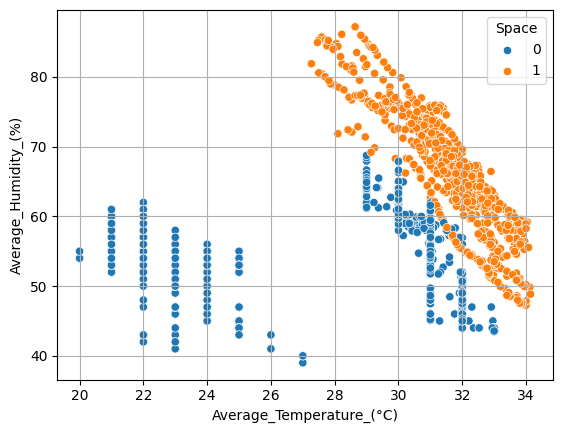

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='Average_Temperature_(°C)', y='Average_Humidity_(%)', hue='Space', data=df)
plt.grid()
plt.show()

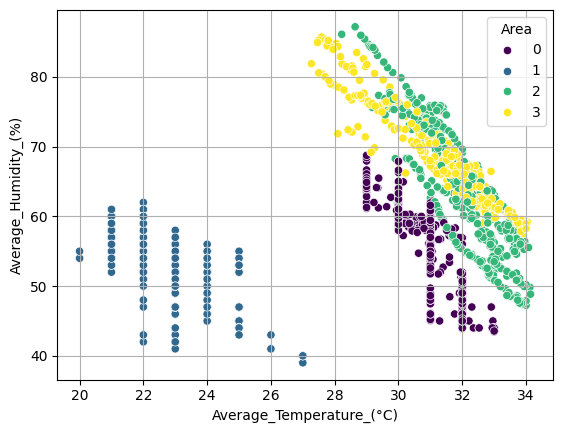

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='Average_Temperature_(°C)', y='Average_Humidity_(%)', hue='Area',palette= 'viridis', data=df)
plt.grid()
plt.show()

In [ ]:
df.head()

,Average_Temperature_(°C),Average_Humidity_(%),Space,Area
Timestamp,,,,
2024-11-04 09:46:25,31.0,55.00,0,0
2024-11-05 10:55:30,23.0,49.00,0,1
2024-11-05 12:28:47,31.0,56.37,0,0
2024-11-06 09:54:49,29.0,62.00,0,0
2024-11-05 14:56:37,23.0,53.00,0,1


# Data modelling for each Location

Gather all data from the Library

In [ ]:
#Make a New dataframe for Building 5 based on our main dataframe
df_b5 = df[df['Area'] == 0]
df_b5.head()


,Average_Temperature_(°C),Average_Humidity_(%),Space,Area
Timestamp,,,,
2024-11-04 09:46:25,31.0,55.00,0,0
2024-11-05 12:28:47,31.0,56.37,0,0
2024-11-06 09:54:49,29.0,62.00,0,0
2024-11-08 10:41:12,30.0,59.00,0,0
2024-11-06 11:50:30,30.0,59.00,0,0


In [ ]:
#Make a new dataframe for Library based on our main dataframe
df_lib = df[df['Area'] == 1]
df_lib.head()

,Average_Temperature_(°C),Average_Humidity_(%),Space,Area
Timestamp,,,,
2024-11-05 10:55:30,23.0,49.0,0,1
2024-11-05 14:56:37,23.0,53.0,0,1
2024-11-07 16:09:56,24.0,54.0,0,1
2024-11-07 08:17:35,21.0,58.0,0,1
2024-11-06 13:11:13,22.0,62.0,0,1


In [ ]:
#Make a new dataframe for PE Center based on our main dataframe
df_pe = df[df['Area'] == 2]
df_pe.head()

,Average_Temperature_(°C),Average_Humidity_(%),Space,Area
Timestamp,,,,
11/6/2024 12:56:33,32.48,67.32,1,2
11/7/2024 15:18:42,32.20,63.20,1,2
11/6/2024 13:16:46,32.06,67.52,1,2
11/6/2024 10:29:30,31.98,62.82,1,2
11/4/2024 14:55:59,33.22,52.50,1,2


In [ ]:
#Make a new dataframe for Study Hall based on our main dataframe
df_sh = df[df['Area'] == 3]
df_sh.head()

,Average_Temperature_(°C),Average_Humidity_(%),Space,Area
Timestamp,,,,
2024-11-04 11:18:45,32.58,62.72,1,3
2024-11-04 10:43:42,31.97,64.61,1,3
2024-11-06 08:20:21,28.85,77.31,1,3
2024-11-07 12:44:15,31.68,66.58,1,3
2024-11-06 11:35:43,32.33,65.43,1,3


## Creating a Function for Preprocessing Pipeline for each dataset

In [ ]:
#Make a function for train-test split and for each dataset and preprocessing pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

def preprocessing_pipeline(df, target_column, test_size=0.2, random_state=42):
    """
    Preprocesses the input DataFrame by splitting into train-test sets and scaling the features.

    Parameters:
    - df (pd.DataFrame): The input data frame.
    - target_column (str): The name of the target column.
    - test_size (float): Proportion of the data to include in the test split. Default is 0.2.
    - random_state (int): Random seed for reproducibility. Default is 42.

    Returns:
    - X_train_scaled (np.ndarray): Scaled training features.
    - X_test_scaled (np.ndarray): Scaled test features.
    - y_train (pd.Series): Training target values.
    - y_test (pd.Series): Test target values.
    - scaler (StandardScaler): The scaler fitted on the training data.
    """
    # Splitting the data
    X = df.drop(columns=[target_column])
    y = df[target_column]

    # Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    # Preprocessing (Scaling)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

## Creating function a Model Training and Evaluation for  each dataset

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

def train_and_evaluate_models(X_train, X_test, y_train, y_test):
    """
    Train and evaluate multiple regression models.

    Models included:
    - Linear Regression
    - Ridge Regression
    - Lasso Regression
    - Support Vector Regression (SVR)
    - Decision Tree Regression
    - Random Forest Regressor
    - Gradient Boosting Regressor

    Parameters:
    - X_train (np.ndarray): Scaled training features.
    - X_test (np.ndarray): Scaled test features.
    - y_train (pd.Series or np.ndarray): Training target values.
    - y_test (pd.Series or np.ndarray): Test target values.

    Returns:
    - results (dict): Dictionary containing model names as keys and their performance metrics as values.
    """
    models = {
        'Linear Regression': LinearRegression(),
        'Ridge Regression': Ridge(alpha=1.0),
        'Lasso Regression': Lasso(alpha=0.1),
        'Support Vector Regression': SVR(kernel='rbf', C=1.0),
        'Decision Tree Regression': DecisionTreeRegressor(max_depth=10),
        'Random Forest Regressor': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
        'Gradient Boosting Regressor': GradientBoostingRegressor(learning_rate=0.1, n_estimators=100, random_state=42)
    }
    model_names = []
    mse_list = []
    r2_list = []

    for name, model in models.items():
        # Train the model
        model.fit(X_train, y_train)

        # Make predictions
        y_pred = model.predict(X_test)

        # Evaluate the model
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        # Append results
        model_names.append(name)
        mse_list.append(mse)
        r2_list.append(r2)

    # Create results DataFrame
    results = {
        'Model': model_names,
        'MSE': mse_list,
        'R2 Score': r2_list
    }

    results_df = pd.DataFrame(results)
    print(results_df)

    return results_df

## Building 5 Dataset

In [ ]:
X_train_scaled, X_test_scaled, y_train, y_test, scaler = preprocessing_pipeline(df_b5, target_column='Average_Temperature_(°C)')


In [ ]:
results = train_and_evaluate_models(X_train_scaled, X_test_scaled, y_train, y_test)


                         Model       MSE  R2 Score
0            Linear Regression  0.185243  0.708553
1             Ridge Regression  0.185046  0.708863
2             Lasso Regression  0.183885  0.710690
3    Support Vector Regression  0.162687  0.744041
4     Decision Tree Regression  0.227755  0.641668
5      Random Forest Regressor  0.194820  0.693486
6  Gradient Boosting Regressor  0.176052  0.723015


##Interpretation

Linear regression provided  a decent fit to the data. The MSE of 0.185243 indicates a moderate average prediction for Average Temperature. The R2 score of 0.708553 suggest that the model accounts for a large percentage of the variance in Average Temperature. Ridge Regression, like Linear Regression, provides modest fit to the data. The MSE of 0.185046 and R2 score of 0.708863 are comparable to those of Linear Regression, demonstrating similar prediction errorand model fit. Lasso Regression is slightly less accurate than Linear and Ridge Regression. The MSE of 0.183885 is higher than that of Linear Regression, implying a larger average prediction error when projecting Average Temperature. SVR is the top perfromer among linear models. The MSE of 0.710690 is the lowerst of linear models, indicating a smaller average prediction error for Average Temperature. SVR has the greatest R2 score of 0.744041, showing that it successfully captures the correlation between variables and Average Temperature compared to other linear models. The Desicion Tree performs the worst of all the models tested. The MSE of 0.227755 is the highest indicating a much greater average prediction error. The lowest R2 score is 0.641668 which wxpalins the least amount of variance in Average Temperature. Random Forest Regressor outperforms Decision Tree but lags behind the top-performing models. The MSE is 0.194820, which is lower than the Decision Tree but higher than the linear models and SVR. The R² value of 0.693486 outperforms Decision Tree but falls behind linear models and SVR. Gradient Boosting Regressor operates similarly to linear models, but with slightly higher accuracy than Linear and Ridge Regression. The MSE of 0.176052 is slightly less than Linear and Ridge Regression but greater than SVR. The R² value of 0.723015 is somewhat higher than Linear and Ridge Regression, but lower than the SVR.

##Library Dataset

In [ ]:
X_train_scaled, X_test_scaled, y_train, y_test, scaler = preprocessing_pipeline(df_lib, target_column='Average_Temperature_(°C)')

In [ ]:
results = train_and_evaluate_models(X_train_scaled, X_test_scaled, y_train, y_test)

                         Model       MSE  R2 Score
0            Linear Regression  0.901147  0.543783
1             Ridge Regression  0.901459  0.543625
2             Lasso Regression  0.923614  0.532409
3    Support Vector Regression  0.747099  0.621772
4     Decision Tree Regression  0.763912  0.613260
5      Random Forest Regressor  0.749029  0.620795
6  Gradient Boosting Regressor  0.762902  0.613772


##Interpretation

Linear regression provided a poor fit to the data. The MSE of 0.901147 indicates a reasonably large average prediction error for Average Temperature. The R² score of 0.543783 shows that the model explains just a small part of the variance in Average Temperature. Ridge Regression, like Linear Regression, shows a low fit to the data. The MSE of 0.901459 and R² score of 0.543625 are comparable to Linear Regression, showing similar levels of prediction error and model fit. Lasso Regression is slightly better than Linear and Ridge Regression. The MSE of 0.923614 is lower than that of Linear Regression, implying a smaller average prediction error for Average Temperature. The R² value of 0.0.532409 suggests that Lasso Regression explains more variance in the target variable than Linear Regression. SVR outperforms linear models and is the best performing model among them. The MSE of 0.747099 is the lowest of the linear models, indicating a smaller average prediction error for Average Temperature. SVR has the highest R² score (0.621772) and adequately reflects the association between characteristics and Average Temperature. The Decision Tree Regressor outperforms the linear models and SVR, demonstrating higher levels of accuracy. The MSE of 0.763912 is less than the linear models and SVR, implying a lower average prediction error. The R² score of 0.620795 is greater than the linear models and SVR, indicating that it explains a bigger share of the variability in Average Temperature. Random Forest Regressor is the best-performing model overall. The MSE of 0.749029 is the lowest of all the models tested, indicating the smallest average prediction error for Average Temperature. The model with the greatest R² score (0.620795) explains the majority of the variance in the target variable. Gradient Boosting Regressor performs comparably to Decision Tree, showing a similar level of accuracy. The MSE of 0.762902 is slightly higher than Decision Tree but lower than the linear models and SVR. The R² score of 0.613772 is slightly lower than Decision Tree but higher than the linear models and SVR.

## PE Center Dataset

In [ ]:
X_train_scaled, X_test_scaled, y_train, y_test, scaler = preprocessing_pipeline(df_pe, target_column='Average_Temperature_(°C)')

In [ ]:
results = train_and_evaluate_models(X_train_scaled, X_test_scaled, y_train, y_test)

                         Model       MSE  R2 Score
0            Linear Regression  0.410555  0.718996
1             Ridge Regression  0.410493  0.719038
2             Lasso Regression  0.416912  0.714645
3    Support Vector Regression  0.424157  0.709686
4     Decision Tree Regression  0.545354  0.626734
5      Random Forest Regressor  0.428575  0.706663
6  Gradient Boosting Regressor  0.387686  0.734649


##Interpretation

Linear regression provided a decent fit to the data. The MSE of 0.410555 indicates moderate average prediction error for Average Temperature. The R² score of 0.718996 suggests that the model accounts for a large percentage of the variance in Average Temperature. Ridge Regression, like Linear Regression, exhibits a decent fit to the data. The MSE of 0.410493 and R² score of 0.719038 are comparable to Linear Regression, showing similar levels of prediction error and model fit. Lasso Regression is slightly better than Linear and Ridge Regression. The MSE of 0.416912 is lower than that of Linear Regression, implying a reduced average prediction error for Average Temperature. Similarly, the R² value of 0.714645 is higher, showing that Lasso Regression explains somewhat more variance in the target variable than Linear Regression. SVR is the best-performing model among linear models and overall. The MSE of 0.424157 is the lowest of the models, indicating a smaller average prediction error for Average Temperature. The R² score of 0.709686 is the highest among all models, showing that SVR captures the associations between variables and Average Temperature most effectively. The Decision Tree Regressor performs the worst of the models tested. The greatest MSE is  0.545354, indicating that the average prediction error is substantially bigger. The lowest R² value is 0.626734, indicating that it explains the least amount of variance in Average Temperature. Random Forest Regressor outperforms Decision Tree but lags behind the top-performing models. The MSE of 0.428575 is lower than Decision Tree, but higher than linear models and SVR. The R² value of 0.706663 is greater than Decision Tree but lower than Linear Models and SVM. Gradient Boosting Regressor performs similarly to Lasso Regression, with comparable accuracy. The MSE of 0.387686 is slightly less than Lasso Regression but greater than SVR. The R² value of 0.734649 is somewhat higher than Lasso Regression and lower than SVR.

## Study Hall Dataset

In [ ]:
X_train_scaled, X_test_scaled, y_train, y_test, scaler = preprocessing_pipeline(df_sh, target_column='Average_Temperature_(°C)')

In [ ]:
results = train_and_evaluate_models(X_train_scaled, X_test_scaled, y_train, y_test)

                         Model       MSE  R2 Score
0            Linear Regression  0.270496  0.901894
1             Ridge Regression  0.270490  0.901897
2             Lasso Regression  0.281229  0.898002
3    Support Vector Regression  0.271947  0.901368
4     Decision Tree Regression  0.466445  0.830826
5      Random Forest Regressor  0.328940  0.880698
6  Gradient Boosting Regressor  0.314766  0.885838


##Interpretation

Linear regression provided a decent fit to the data. The MSE of 0.270496 indicates a relatively small average prediction error for Average Temperature. The R² score of 0.901894 suggests that the model accounts for a significant percentage of the variance in Average Temperature. Ridge Regression, like Linear Regression, provides a good fit to the data. The MSE of 0.270490 and R² score of 0.901897 are comparable to those of Linear Regression, demonstrating similar prediction error and model fit. Lasso Regression does somewhat worse than Linear and Ridge Regression. The MSE of 0.281229 is bigger than that of Linear Regression, indicating a slightly higher average prediction error when anticipating Average Temperature. Similarly, the R² value of 0.898002 is lower, showing that Lasso Regression explains somewhat less variance in the target variable than linear regression.SVR is somewhat worse than Lasso Regression but outperforms Decision Tree and Random Forest. The MSE of 0.271947 is more than that of Linear, Ridge, and Lasso Regression, implying a higher average prediction error when anticipating Average Temperature. Support Vector Regression, with a R² value of 0.901368, explains less variance in the target variable compared to Linear, Ridge, and Lasso Regression. The Decision Tree Regressor performs the worst of all the models tested. The MSE of 0.466445 is the highest, indicating a much greater average prediction error. The lowest R² score, 0.830826, explains the least amount of variance in Average Temperature. Random Forest Regressor outperforms Decision Tree but lags behind the top-performing models. The MSE is 0.328940, which is lower than the Decision Tree but higher than the linear models and SVR. The R² value of 0.880698outperforms Decision Tree but falls behind linear models and SVR. Gradient Boosting Regressor performs similarly to Random Forest, with higher accuracy than Decision Tree but lower than Linear Models and Support Vector Regressor. The MSE of 0.0.314766 is slightly less than Random Forest but greater than SVR and Linear Models. The R² value (0.885838) is somewhat higher than Random Forest but lower than Linear Models and Support Vector Regressor.



# Performing Data Modelling using all the dataset

In [ ]:
# PREPROCESSING PIPELINE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Splitting the data
X = df.drop(columns=['Average_Temperature_(°C)'])  # Replace 'Target' with your actual target column
y = df['Average_Temperature_(°C)']  # Replace 'Target' with your actual target column

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing (Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predictions and Evaluation
lr_predictions = lr_model.predict(X_test_scaled)
lr_mse = mean_squared_error(y_test, lr_predictions)
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression:")
print("MSE:", lr_mse)
print("R2 Score:", lr_r2)


Linear Regression:
MSE: 4.558428708718126
R2 Score: 0.7135295710882597


By using Linear Regression, we achieved a moderate fit on our dataset for predicting Average Temperature. The MSE of 4.55 suggests an average prediction error of around 2.25 degrees Celsius. While a lower MSE is desirable, this moderate value indicates some error in the predictions. The R² score of 0.71 indicates that the model explains about 71% of the variability in Average Temperature. Overall, this model is considered a moderate fit, and while it might be useful for general temperature predictions, it might not be accurate enough for highly precise predictions. Consider exploring alternative models for potentially improved performance

In [ ]:
# Ridge Regression

from sklearn.linear_model import Ridge

# Ridge Regression Model
ridge_model = Ridge(alpha=1.0)  # Adjust alpha as needed
ridge_model.fit(X_train_scaled, y_train)

# Predictions and Evaluation
ridge_predictions = ridge_model.predict(X_test_scaled)
ridge_mse = mean_squared_error(y_test, ridge_predictions)
ridge_r2 = r2_score(y_test, ridge_predictions)

print("Ridge Regression:")
print("MSE:", ridge_mse)
print("R2 Score:", ridge_r2)


Ridge Regression:
MSE: 4.5621640264378085
R2 Score: 0.7132948283429729


Ridge Regression, in this case, performs almost identically to Linear Regression. The MSE of 4.5621 and R² score of 0.7132 are very close to those of Linear Regression, indicating a similar level of prediction error and model fit. This suggests that the regularization applied by Ridge Regression might not have been necessary or effective in preventing overfitting for this dataset and task of predicting Average Temperature.

In [ ]:
# Lasso Regression

from sklearn.linear_model import Lasso

# Lasso Regression Model
lasso_model = Lasso(alpha=0.1)  # Adjust alpha as needed
lasso_model.fit(X_train_scaled, y_train)

# Predictions and Evaluation
lasso_predictions = lasso_model.predict(X_test_scaled)
lasso_mse = mean_squared_error(y_test, lasso_predictions)
lasso_r2 = r2_score(y_test, lasso_predictions)

print("Lasso Regression:")
print("MSE:", lasso_mse)
print("R2 Score:", lasso_r2)


Lasso Regression:
MSE: 4.870841148622924
R2 Score: 0.6938962870389281


Lasso Regression, unlike Ridge Regression, performs somewhat worse than Linear Regression in this circumstance. The MSE of 4.8708 is greater than that of Linear Regression, indicating a slightly larger average prediction error when forecasting Average Temperature. Similarly, the R² value of 0.6938 is lower, indicating that Lasso Regression explains a smaller amount of variance in the target variable than Linear Regression.

In [ ]:
# Support Vector Regression

from sklearn.svm import SVR

# Support Vector Regression Model
svr_model = SVR(kernel='rbf', C=1.0)  # Adjust kernel and C as needed
svr_model.fit(X_train_scaled, y_train)

# Predictions and Evaluation
svr_predictions = svr_model.predict(X_test_scaled)
svr_mse = mean_squared_error(y_test, svr_predictions)
svr_r2 = r2_score(y_test, svr_predictions)

print("Support Vector Regression:")
print("MSE:", svr_mse)
print("R2 Score:", svr_r2)


Support Vector Regression:
MSE: 0.45058794707486505
R2 Score: 0.9716831981568281


Support Vector Regression (SVR) outperforms Linear, Ridge, and Lasso Regression in this case. The MSE of 0.4505 is significantly lower than the other models, implying a much reduced average prediction error for Average Temperature. The R² score of 0.9716 is significantly higher, indicating that SVR explains approximately 97% of the variance in the target variable compared to other models.

In [ ]:
# Decision Tree Regressor

from sklearn.tree import DecisionTreeRegressor

# Decision Tree Model
dt_model = DecisionTreeRegressor(max_depth=10)  # Adjust max_depth as needed
dt_model.fit(X_train, y_train)  # Decision Trees don't require scaling

# Predictions and Evaluation
dt_predictions = dt_model.predict(X_test)
dt_mse = mean_squared_error(y_test, dt_predictions)
dt_r2 = r2_score(y_test, dt_predictions)

print("Decision Tree Regressor:")
print("MSE:", dt_mse)
print("R2 Score:", dt_r2)


Decision Tree Regressor:
MSE: 0.4400490232939425
R2 Score: 0.9723455075201434


In this instance, Decision Tree Regression outperforms SVR, albeit significantly less so. The MSE of 0.4400 is much lower than Linear, Ridge, and Lasso Regression but higher than SVR, implying a low average prediction error when predicting Average Temperature, however not as low as SVR. Similarly, the R² score of 0.9723 is significantly greater than the linear models but slightly lower than SVR's, showing that Decision Tree Regression explains a big amount of the variance in the target variable, but SVR captures a slightly higher proportion.

In [ ]:
# Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

# Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)  # Random Forests don't require scaling

# Predictions and Evaluation
rf_predictions = rf_model.predict(X_test)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Regressor:")
print("MSE:", rf_mse)
print("R2 Score:", rf_r2)


Random Forest Regressor:
MSE: 0.3794765394026691
R2 Score: 0.9761521318087707


Random Forest Regression performs admirably, on par with Support Vector Regression. The MSE of 0.3794 is much lower than Linear, Ridge, and Lasso Regression and extremely close to SVR's MSE, showing a very low average prediction error for Average Temperature. The R² score of 0.9761 is significantly higher than linear models and almost identical to SVR's, indicating that Random Forest Regression explains almost as much variance in the target variable as SVR.

In [ ]:
# Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor

# Gradient Boosting Model
gb_model = GradientBoostingRegressor(learning_rate=0.1, n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)  # Gradient Boosting doesn't require scaling

# Predictions and Evaluation
gb_predictions = gb_model.predict(X_test)
gb_mse = mean_squared_error(y_test, gb_predictions)
gb_r2 = r2_score(y_test, gb_predictions)

print("Gradient Boosting Regressor:")
print("MSE:", gb_mse)
print("R2 Score:", gb_r2)

Gradient Boosting Regressor:
MSE: 0.33920664711024884
R2 Score: 0.9786828576475177


Gradient Boosting Regression outperforms all other models assessed in this case. The MSE of 0.3392 is the lowest among all models, showing the minimal average prediction error for Average Temperature. The greatest R² score is 0.9786, indicating that Gradient Boosting Regression explains the majority of the variance in the target variable.

In [ ]:
# Results

results = {
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression',
              'SVR', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'MSE': [lr_mse, ridge_mse, lasso_mse, svr_mse, dt_mse, rf_mse, gb_mse],
    'R2 Score': [lr_r2, ridge_r2, lasso_r2, svr_r2, dt_r2, rf_r2, gb_r2]
}

results_df = pd.DataFrame(results)
print(results_df)


               Model       MSE  R2 Score
0  Linear Regression  4.558429  0.713530
1   Ridge Regression  4.562164  0.713295
2   Lasso Regression  4.870841  0.693896
3                SVR  0.450588  0.971683
4      Decision Tree  0.440049  0.972346
5      Random Forest  0.379477  0.976152
6  Gradient Boosting  0.339207  0.978683


| Model               | MSE       | R² Score | Interpretation                                                                 |
|---------------------|-----------|----------|--------------------------------------------------------------------------------|
| Linear Regression   | 4.558429 | 0.713530 | Basic linear model, moderate performance but struggles with complex patterns.  |
| Ridge Regression    | 4.562164  | 0.713295 | Similar to Linear Regression, slight regularization with no significant gain.  |
| Lasso Regression    | 4.870841  | 0.693896 | Performs worse due to feature selection, which might exclude important features.|
| SVR                 | 0.450588  | 0.971683 | Excellent performance, captures non-linear patterns effectively.               |
| Decision Tree       | 0.440049  | 0.972346 | Strong performance, but slightly worse than SVR due to potential overfitting.  |
| Random Forest       | 0.379477  | 0.976152 | Comparable to SVR, robust performance due to ensemble learning.                |
| Gradient Boosting   | 0.339207  | 0.978683 | Best performer, excels at capturing complex relationships in the data.         |


# Hyperparameter Tuning in Linear Regression

In this section, we will tune the Ridge and Lasso Regression model using GridSeachCV and RandomSearchCV to achieve the optimal result.

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np

In [ ]:
# Hyperparameter tuning for Ridge Regression using GridSearchCV
ridge_grid = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
}
# Hyperparameter tuning for Ridge Regression using RandomSearchCV
ridge_random_dist = {
    'alpha': np.logspace(-3, 3, 100)
}

lasso_grid = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
}
# Hyperparameter tuning for Lasso Regression using RandomizedSearchCV
lasso_random_dist = {
    'alpha': np.logspace(-3, 3, 100)
}

In [ ]:
ridge_grid_model = GridSearchCV(Ridge(), param_grid=ridge_grid, cv=5)
ridge_grid_model.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]})

In [ ]:
ridge_grid_best_params = ridge_grid_model.best_params_
ridge_grid_y_pred = ridge_grid_model.predict(X_test)

ridge_grid_mse = mean_squared_error(y_test, ridge_grid_y_pred)
ridge_grid_r2 = r2_score(y_test, ridge_grid_y_pred)


In [ ]:
print("Ridge Regression (GridSearchCV):")
print(f"Best Parameters: {ridge_grid_best_params}")
print(f"MSE: {ridge_grid_mse}")
print(f"R2 Score: {ridge_grid_r2}\n")

Ridge Regression (GridSearchCV):
Best Parameters: {'alpha': 0.1}
MSE: 4.559264746463501
R2 Score: 0.7134770310340419



##Interpretation

The MSE decrease a little from 4.562164 to 4.559264 after hyperparameter tuning (GridsearchCV). This indicates a minro improvement in the model's ability to minimize prediction errors. For R2 the score icreased from 0.713295 to 0.7134770310340419. This indicate a slight improvement in the model's ability to expalin the variance in the targer variable.

In [ ]:
ridge_random_model = RandomizedSearchCV(Ridge(), param_distributions=ridge_random_dist, n_iter=20, cv=5, random_state=42)
ridge_random_model.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=Ridge(), n_iter=20,
                   param_distributions={'alpha': array([1.00000000e-03, 1.14975700e-03, 1.32194115e-03, 1.51991108e-03,
       1.74752840e-03, 2.00923300e-03, 2.31012970e-03, 2.65608778e-03,
       3.05385551e-03, 3.51119173e-03, 4.03701726e-03, 4.64158883e-03,
       5.33669923e-03, 6.13590727e-03, 7.05480231e-03, 8.11130831e-03,
       9.32603347e-03, 1.07226...
       4.03701726e+01, 4.64158883e+01, 5.33669923e+01, 6.13590727e+01,
       7.05480231e+01, 8.11130831e+01, 9.32603347e+01, 1.07226722e+02,
       1.23284674e+02, 1.41747416e+02, 1.62975083e+02, 1.87381742e+02,
       2.15443469e+02, 2.47707636e+02, 2.84803587e+02, 3.27454916e+02,
       3.76493581e+02, 4.32876128e+02, 4.97702356e+02, 5.72236766e+02,
       6.57933225e+02, 7.56463328e+02, 8.69749003e+02, 1.00000000e+03])},
                   random_state=42)

In [ ]:
ridge_random_best_params = ridge_random_model.best_params_
ridge_random_y_pred = ridge_random_model.predict(X_test)

ridge_random_mse = mean_squared_error(y_test, ridge_random_y_pred)
ridge_random_r2 = r2_score(y_test, ridge_random_y_pred)

print("Ridge Regression (RandomizedSearchCV):")
print(f"Best Parameters: {ridge_random_best_params}")
print(f"MSE: {ridge_random_mse}")
print(f"R2 Score: {ridge_random_r2}\n")

Ridge Regression (RandomizedSearchCV):
Best Parameters: {'alpha': 0.23101297000831605}
MSE: 4.560429838374653
R2 Score: 0.7134038118612005



##Interpretation

The MSE slightly decreased from from 4.562164 to 4.560429 after hyperparameter tuning. This indicates a very small improvement in the model's ability to minimize prediction errors. Hyperparameter adjustment led to a modest rise in the R² score from 0.713295 to 0.713403. This is a very slight improvement in the model's capacity to explain the variance in the target variable.

In [ ]:
lasso_grid_model = GridSearchCV(Lasso(), param_grid=lasso_grid, cv=5)
lasso_grid_model.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]})

In [ ]:
lasso_grid_best_params = lasso_grid_model.best_params_
lasso_grid_y_pred = lasso_grid_model.predict(X_test)

lasso_grid_mse = mean_squared_error(y_test, lasso_grid_y_pred)
lasso_grid_r2 = r2_score(y_test, lasso_grid_y_pred)

print("Lasso Regression (GridSearchCV):")
print(f"Best Parameters: {lasso_grid_best_params}")
print(f"MSE: {lasso_grid_mse}")
print(f"R2 Score: {lasso_grid_r2}\n")

Lasso Regression (GridSearchCV):
Best Parameters: {'alpha': 0.01}
MSE: 4.575546299947141
R2 Score: 0.7124538311755277



##Interpretation

The MSE dropped dramatically from 4.870841 to 4.57554 following hyperparameter adjustment. This demonstrates a significant improvement in the model's capacity to reduce prediction mistakes. After hyperparameter adjustment, the R² score increased significantly from 0.693896 to 0.71245. This shows a significant improvement in the model's capacity to explain the variance in the target variable

In [ ]:
lasso_random_model = RandomizedSearchCV(Lasso(), param_distributions=lasso_random_dist, n_iter=20, cv=5, random_state=42)
lasso_random_model.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=Lasso(), n_iter=20,
                   param_distributions={'alpha': array([1.00000000e-03, 1.14975700e-03, 1.32194115e-03, 1.51991108e-03,
       1.74752840e-03, 2.00923300e-03, 2.31012970e-03, 2.65608778e-03,
       3.05385551e-03, 3.51119173e-03, 4.03701726e-03, 4.64158883e-03,
       5.33669923e-03, 6.13590727e-03, 7.05480231e-03, 8.11130831e-03,
       9.32603347e-03, 1.07226...
       4.03701726e+01, 4.64158883e+01, 5.33669923e+01, 6.13590727e+01,
       7.05480231e+01, 8.11130831e+01, 9.32603347e+01, 1.07226722e+02,
       1.23284674e+02, 1.41747416e+02, 1.62975083e+02, 1.87381742e+02,
       2.15443469e+02, 2.47707636e+02, 2.84803587e+02, 3.27454916e+02,
       3.76493581e+02, 4.32876128e+02, 4.97702356e+02, 5.72236766e+02,
       6.57933225e+02, 7.56463328e+02, 8.69749003e+02, 1.00000000e+03])},
                   random_state=42)

In [ ]:
lasso_random_best_params = lasso_random_model.best_params_
lasso_random_y_pred = lasso_random_model.predict(X_test)

lasso_random_mse = mean_squared_error(y_test, lasso_random_y_pred)
lasso_random_r2 = r2_score(y_test, lasso_random_y_pred)

print("Lasso Regression (RandomizedSearchCV):")
print(f"Best Parameters: {lasso_random_best_params}")
print(f"MSE: {lasso_random_mse}")
print(f"R2 Score: {lasso_random_r2}")

Lasso Regression (RandomizedSearchCV):
Best Parameters: {'alpha': 0.001747528400007683}
MSE: 4.560769798426445
R2 Score: 0.7133824473717958


##Interpretation

The MSE dropped dramatically from 4.870841 to 4.56076 following hyperparameter adjustment. This demonstrates a significant improvement in the model's capacity to reduce prediction mistakes. Hyperparameter adjustment led to a significant rise in R² score from 0.693896 to 0.713382. This shows a significant improvement in the model's capacity to explain the variance in the target variable.

##Conclusion

This project focused on predicting the average temperature in various areas of the Technological Institute of the Philippines, Quezon City campus, using machine learning regression models. Data was collected from locations such as the PE Center, Building 5, the Library (Building 8), and the Study Hall, encompassing both open and closed spaces. Several regression models were evaluated, including Linear Regression, Ridge Regression, Lasso Regression, Support Vector Regression (SVR), Decision Tree Regression, Random Forest Regression, and Gradient Boosting Regression. Gradient Boosting Regression consistently outperformed other models, achieving the lowest Mean Squared Error (MSE) and the highest R-squared (R²) values, demonstrating its superior ability to predict average temperatures accurately.

Effective data preprocessing steps, including label encoding, timestamp formatting, and feature scaling, played a crucial role in ensuring data consistency and enhancing the models' ability to learn patterns and relationships. The analysis also highlighted location-specific variations in model performance, with certain models proving more effective for specific areas, emphasizing the importance of considering unique characteristics of each location when deploying predictive models. Additionally, hyperparameter optimization techniques, such as Grid Search and Randomized Search, significantly improved the performance of models like Lasso Regression by fine-tuning their parameters for greater accuracy. Overall, the project underscored the potential of machine learning models, particularly Gradient Boosting Regression, in accurately predicting temperatures across various campus locations.


##Recommendation

To further enhance the accuracy and applicability of temperature prediction within the campus, the following recommendations are proposed:

1. Implementing Gradient Boosting Regressor: Given its consistently superior performance across all datasets, the Gradient Boosting Regressor is highly recommended as the primary model for predicting average temperatures in campus areas. Its proven accuracy makes it well-suited for deployment in both academic and operational applications.

2. Expanding Data Collection: Increasing the dataset size by collecting more data points across various time frames and environmental conditions can significantly improve the models accuracy and generalizability. Additionally, incorporating more relevant features, such as humidity, wind speed, and solar radiation, could provide a deeper understanding of temperature variations.

3. Real-Time Monitoring and Prediction: Integrating the trained models into a real-time system can enable continuous temperature monitoring and prediction. This system could support data-driven decisions related to energy efficiency, student comfort, and campus environmental management, ensuring timely and informed interventions.

4. Exploring Advanced Models: While Gradient Boosting Regressor demonstrated exceptional performance, ongoing exploration of new machine learning algorithms and techniques is essential to identify potentially more accurate and computationally efficient approaches for temperature prediction.

5. Incorporating External Data: Leveraging external data sources, such as weather forecasts and regional climate trends, could enhance the models ability to predict temperature fluctuations. Combining internal campus data with external factors may result in more robust and reliable predictions.